# Sanity check - pre process functions
paseo - Estopa

In [12]:
%load_ext autoreload
%autoreload 2
import tools_EEG as TEEG

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


let's check that the main functions related to the pre-process are working as expected. 


In [ ]:
input_dir = "/home/tperezsanchez/FoundationModel_EEG_Dissertation/EEG_data_vis/data/Working/XB47Y/"


## CHECK THAT THE AMPLITUDE CUT-OFF IS WORKING!

In [32]:
import os
import pandas as pd
import scipy.io as sio
#input
file_name = "/home/tperezsanchez/FoundationModel_EEG_Dissertation/EEG_data_vis/data/Working/XB47Y/XB47Y_181.mat"   # <-- un solo archivo
output_dir = "/home/tperezsanchez/FoundationModel_EEG_Dissertation/EEG_data_vis/results/sanitycheck07032026"   # <-- un solo archivo

mat_path = file_name
base_name = os.path.splitext(file_name)[0]
#check if the path does not exist
if not os.path.exists(mat_path):
    raise FileNotFoundError(f"File not found: {mat_path}")

print(f"\n--- Processing single file: {file_name} ---")
# load mat file
mat_contents = sio.loadmat(mat_path)
header_dict = mat_contents["hdr"]
# generate array (time + channels)
_, _, df_eeg = TEEG.build_eeg_array_from_mat_1_6(
    hdr=header_dict,
    mat_data=mat_contents,
    output_dir=output_dir,
    file_prefix=base_name,
    save_format= "npz",
    return_dataframe=True
)
# identify columns of signal
channel_cols = [c for c in df_eeg.columns if c != "Time"]
# checks
print("df_eeg shape:", df_eeg.shape)
print("Columns:", df_eeg.columns.tolist()[:10])
print("Number of channels:", len(channel_cols))
print("First channels:", channel_cols[:5])

print("\nHead of df_eeg:")
print(df_eeg.head())

print("\nDtypes:")
print(df_eeg.dtypes.head(10))

print("\nMax absolute amplitude before cutoff:")
print(df_eeg[channel_cols].abs().max().sort_values(ascending=False).head(10))



--- Processing single file: /home/tperezsanchez/FoundationModel_EEG_Dissertation/EEG_data_vis/data/Working/XB47Y/XB47Y_181.mat ---
Saved EEG data to: /home/tperezsanchez/FoundationModel_EEG_Dissertation/EEG_data_vis/data/Working/XB47Y/XB47Y_181.npz
Shape: (4472028, 2)
Sampling frequency: 207.0310546581987 Hz
df_eeg shape: (4472028, 3)
Columns: ['Time', 'EEG SQ_D-SQ_C', 'EEG SQ_P-SQ_C']
Number of channels: 2
First channels: ['EEG SQ_D-SQ_C', 'EEG SQ_P-SQ_C']

Head of df_eeg:
       Time  EEG SQ_D-SQ_C  EEG SQ_P-SQ_C
0  0.000000    -114.741081    -124.135094
1  0.004830     236.863174     216.062164
2  0.009660     100.650070      63.745045
3  0.014491     -87.901062    -120.780090
4  0.019321    -439.505310    -448.228333

Dtypes:
Time             float64
EEG SQ_D-SQ_C    float32
EEG SQ_P-SQ_C    float32
dtype: object

Max absolute amplitude before cutoff:
EEG SQ_D-SQ_C    1374.208984
EEG SQ_P-SQ_C    1374.208984
dtype: float32


In [33]:
df_cut = TEEG.apply_amplitude_cutoff_1_5(
    EEG_Table=df_eeg,
    threshold=200
)

print("\nHead after cutoff:")
print(df_cut.head())

print("\nMax absolute amplitude after cutoff:")
print(df_cut[channel_cols].abs().max().sort_values(ascending=False).head(10))


Head after cutoff:
       Time  EEG SQ_D-SQ_C  EEG SQ_P-SQ_C
0  0.000000    -114.741081    -124.135094
1  0.004830     200.000000     200.000000
2  0.009660     100.650070      63.745045
3  0.014491     -87.901062    -120.780090
4  0.019321    -200.000000    -200.000000

Max absolute amplitude after cutoff:
EEG SQ_D-SQ_C    200.0
EEG SQ_P-SQ_C    200.0
dtype: float32


In [34]:
print(df_eeg[channel_cols].abs().max().sort_values(ascending=False).head(10))
print ("--------")
print(df_cut[channel_cols].abs().max().sort_values(ascending=False).head(10))

EEG SQ_D-SQ_C    1374.208984
EEG SQ_P-SQ_C    1374.208984
dtype: float32
--------
EEG SQ_D-SQ_C    200.0
EEG SQ_P-SQ_C    200.0
dtype: float32


In [35]:
n_above_before = (df_eeg[channel_cols].abs() > 200).sum().sum()
n_above_after = (df_cut[channel_cols].abs() > 200).sum().sum()

print("Samples above 200 before cutoff:", n_above_before)
print("Samples above 200 after cutoff:", n_above_after)

Samples above 200 before cutoff: 350151
Samples above 200 after cutoff: 0


## Sanity check band pass


In [64]:
EEG_win = df_cut.set_index("Time")[channel_cols].copy()
print("Shape:", EEG_win.shape)
print("Index type:", type(EEG_win.index))
print("First index values:", EEG_win.index[:5].tolist())
print("Columns:", EEG_win.columns[:5].tolist())
print("Any NaNs?:", EEG_win.isna().any().any())

Shape: (4472028, 2)
Index type: <class 'pandas.core.indexes.base.Index'>
First index values: [0.0, 0.004830193236714977, 0.009660386473429953, 0.014490579710144929, 0.019320772946859906]
Columns: ['EEG SQ_D-SQ_C', 'EEG SQ_P-SQ_C']
Any NaNs?: False


In [65]:
import numpy as np

t = EEG_win.index.to_numpy(dtype=float)
dt = np.median(np.diff(t))
fs_est = 1.0 / dt
nyq = fs_est / 2.0

print("dt =", dt)
print("fs_est =", fs_est)
print("nyquist =", nyq)
print(header_dict['Fs'])

dt = 0.004830193236557534
fs_est = 207.031054664947
nyquist = 103.5155273324735
[[array([[207.03105466]])]]


In [66]:
t = EEG_win.index.to_numpy(dtype=float)
dts = np.diff(t)

print("dt min:", dts.min())
print("dt max:", dts.max())
print("dt median:", np.median(dts))
print("dt mean:", np.mean(dts))
print("dt std:", np.std(dts))

dt min: 0.004830193236557534
dt max: 0.004830193240195513
dt median: 0.004830193236557534
dt mean: 0.004830193236714977
dt std: 5.089651060937268e-13


In [67]:
EEG_win = df_cut.set_index("Time")[channel_cols].copy()

t = EEG_win.index.to_numpy(dtype=float)
dts = np.diff(t)

print("dt min:", dts.min())
print("dt max:", dts.max())
print("dt median:", np.median(dts))
print("dt mean:", np.mean(dts))
print("dt std:", np.std(dts))
print("fs from median:", 1.0 / np.median(dts))
print("fs from mean:", 1.0 / np.mean(dts))

dt min: 0.004830193236557534
dt max: 0.004830193240195513
dt median: 0.004830193236557534
dt mean: 0.004830193236714977
dt std: 5.089651060937268e-13
fs from median: 207.031054664947
fs from mean: 207.03105465819868


In [68]:
EEG_win = df_cut.set_index("Time")[channel_cols].copy()

EEG_test = EEG_win.loc[(EEG_win.index >= 100) & (EEG_win.index <= 110)].copy()

print("EEG_test shape:", EEG_test.shape)
print("Time min:", EEG_test.index.min())
print("Time max:", EEG_test.index.max())

EEG_test shape: (2070, 2)
Time min: 100.00432077294687
Time max: 109.99799057971015


In [69]:
EEG_test_filt, fs = TEEG.bandpass_filter_eegwin_1_8(
    EEG_win=EEG_test,
    lowcut=0.5,
    highcut=48.0,
    order=4,
    check_nans=True
)
print("Returned fs:", fs)
print("Filtered shape:", EEG_test_filt.shape)
print("Same shape?:", EEG_test_filt.shape == EEG_test.shape)
print("Same index?:", EEG_test_filt.index.equals(EEG_test.index))
print("Same columns?:", list(EEG_test_filt.columns) == list(EEG_test.columns))
print("NaNs after filtering?:", EEG_test_filt.isna().any().any())

Returned fs: 207.03105465824683
Filtered shape: (2070, 2)
Same shape?: True
Same index?: True
Same columns?: True
NaNs after filtering?: False


In [70]:
diff = EEG_test_filt - EEG_test

print("Max abs diff:", diff.abs().max().max())
print("Mean abs diff:", diff.abs().mean().mean())

Max abs diff: 111.9496337572072
Mean abs diff: 14.778577810893156


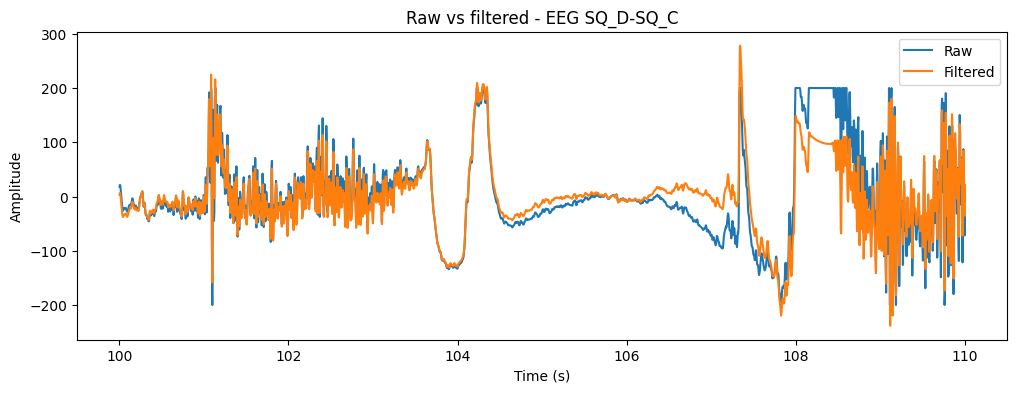

In [71]:
import matplotlib.pyplot as plt

ch = EEG_test.columns[0]

plt.figure(figsize=(12,4))
plt.plot(EEG_test.index, EEG_test[ch], label="Raw")
plt.plot(EEG_test_filt.index, EEG_test_filt[ch], label="Filtered")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Raw vs filtered - {ch}")
plt.legend()
plt.show()

In [73]:
print("Max abs before filtering:", EEG_test[ch].abs().max())
print("Max abs after filtering:", EEG_test_filt[ch].abs().max())

Max abs before filtering: 200.0
Max abs after filtering: 278.0197177118156


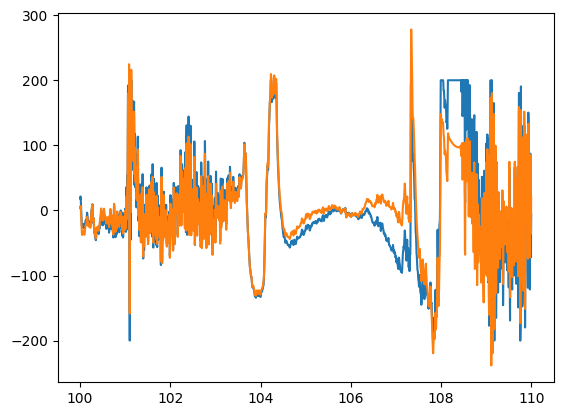

In [74]:
plt.plot(EEG_test.index, EEG_test[ch], label="Clipped")
plt.plot(EEG_test_filt.index, EEG_test_filt[ch], label="Clipped + Filtered")

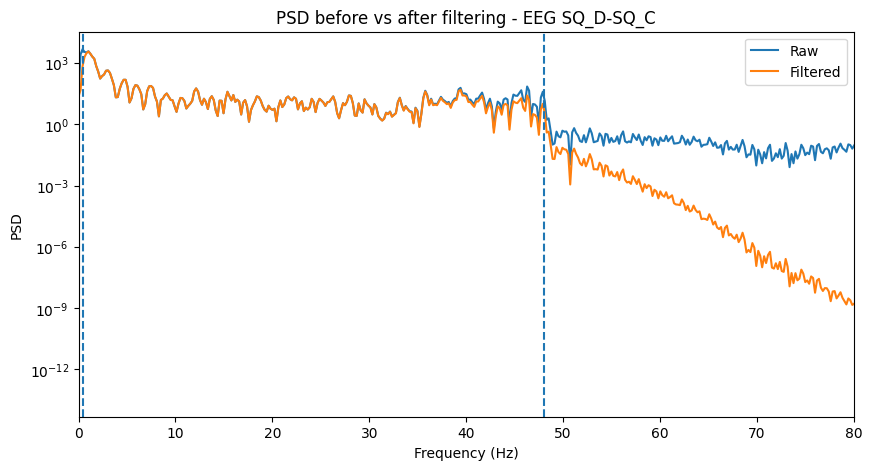

In [72]:
from scipy.signal import welch
import matplotlib.pyplot as plt

ch = EEG_test.columns[0]

x_raw = EEG_test[ch].to_numpy()
x_filt = EEG_test_filt[ch].to_numpy()

f_raw, p_raw = welch(x_raw, fs=fs, nperseg=min(1024, len(x_raw)))
f_filt, p_filt = welch(x_filt, fs=fs, nperseg=min(1024, len(x_filt)))

plt.figure(figsize=(10,5))
plt.semilogy(f_raw, p_raw, label="Raw")
plt.semilogy(f_filt, p_filt, label="Filtered")
plt.axvline(0.5, linestyle="--")
plt.axvline(48.0, linestyle="--")
plt.xlim(0, min(80, fs/2))
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title(f"PSD before vs after filtering - {ch}")
plt.legend()
plt.show()